In [32]:
import pymcel as pc 
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [21]:
G = 1

In [25]:
sistema = [
    dict(m=1, r=np.array([0, 0, 0]), v=np.array([0, 0, 0])),
    # dict(m=0.01, r=np.array([1, 0, 0]), v=np.array([0, 1, 0])) no se escapa 
    # dict(m=0.01, r=np.array([1, 0, 0]), v=np.array([0, 2, 0])) # se escapa
    dict(m=0.01, r=np.array([1, 0, 0]), v=np.array([0, np.sqrt(2*G*1/1), 0])) # órbita parabólica
]

Energía total $E = K+U$

In [26]:
K = 0.5 *sistema[0]['m'] * np.linalg.norm(sistema[0]['v'])**2 + \
    0.5 *sistema[1]['m'] * np.linalg.norm(sistema[1]['v'])**2

K

0.010000000000000002

In [27]:
G = 1 #Unidades canónicas 
U = -G * sistema[0]['m'] * sistema[1]['m'] / \
    np.linalg.norm(sistema[0]['r'] - sistema[1]['r'])

U

-0.01

In [28]:
E = K + U

E

1.734723475976807e-18

Ahora se va a probar si efectivamente el cuerpo no escapa

In [29]:
ts = np.linspace(0, 10, 100)
rs, vs, rps, vps, cuadraturas = pc.ncuerpos_solucion(sistema, ts)

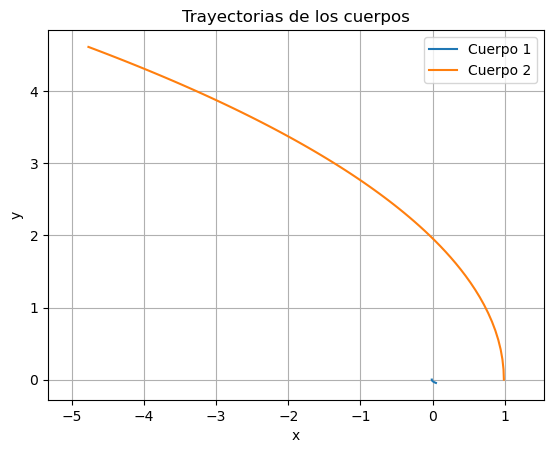

In [30]:
plt.plot(rps[0,:,0], rps[0,:,1], label='Cuerpo 1')
plt.plot(rps[1,:,0], rps[1,:,1], label='Cuerpo 2')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Trayectorias de los cuerpos')
plt.legend()
plt.axis('equal')
plt.grid()
plt.show()



In [33]:
fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=rps[0,:,0], y=rps[0,:,1], z=rps[0,:,2],
    mode='lines',
    name='Cuerpo 1'
))

fig.add_trace(go.Scatter3d(
    x=rps[1,:,0], y=rps[1,:,1], z=rps[1,:,2],
    mode='lines',
    name='Cuerpo 2'
))

fig.update_layout(
    title='Trayectorias 3D de los cuerpos',
    scene=dict(
        xaxis_title='x',
        yaxis_title='y',
        zaxis_title='z'
    )
)

fig.show()

Hacer la simulación con Rebound 

In [34]:
import rebound as rb

In [43]:
sim = rb.Simulation()
sim.G 
sim.add(m=1) #está párticula se crea en el origen con velocidad cero por defecto
sim.add(m=0.01, x=1, vy = 1) #se crea a 1 unidad del origen con una velocidad tangencial de 0.01 unidades

In [44]:
ts = np.linspace(0, 10, 100)
rs = np.zeros((2,100,3))
vs = np.zeros((2,100,3))
rps = np.zeros((2,100,3))
vps = np.zeros((2,100,3))

for i, t in enumerate(ts):
    sim.integrate(t)
    rs[0,i] = sim.particles[0].xyz
    vs[0,i] = sim.particles[0].vxyz
    rs[1,i] = sim.particles[1].xyz
    vs[1,i] = sim.particles[1].vxyz 

    sim.move_to_com() #mueve el sistema al centro de masa
    rps[0,i] = sim.particles[0].xyz
    vps[0,i] = sim.particles[0].vxyz
    rps[1,i] = sim.particles[1].xyz
    vps[1,i] = sim.particles[1].vxyz    


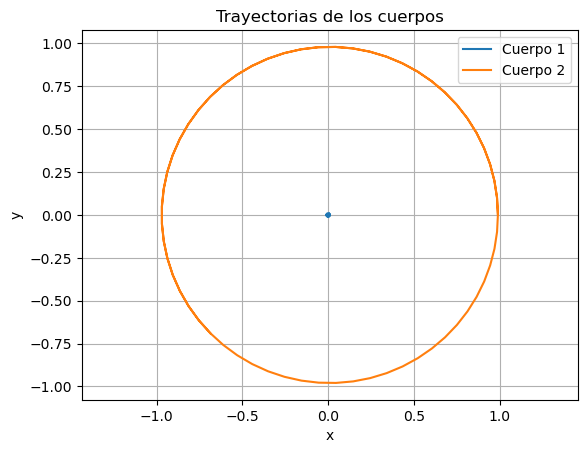

In [45]:
plt.plot(rps[0,:,0], rps[0,:,1], label='Cuerpo 1')
plt.plot(rps[1,:,0], rps[1,:,1], label='Cuerpo 2')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Trayectorias de los cuerpos')
plt.legend()
plt.axis('equal')
plt.grid()
plt.show()



In [46]:
fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=rps[0,:,0], y=rps[0,:,1], z=rps[0,:,2],
    mode='lines',
    name='Cuerpo 1'
))

fig.add_trace(go.Scatter3d(
    x=rps[1,:,0], y=rps[1,:,1], z=rps[1,:,2],
    mode='lines',
    name='Cuerpo 2'
))

fig.update_layout(
    title='Trayectorias 3D de los cuerpos',
    scene=dict(
        xaxis_title='x',
        yaxis_title='y',
        zaxis_title='z'
    )
)

fig.show()